# Evaluating generative text models

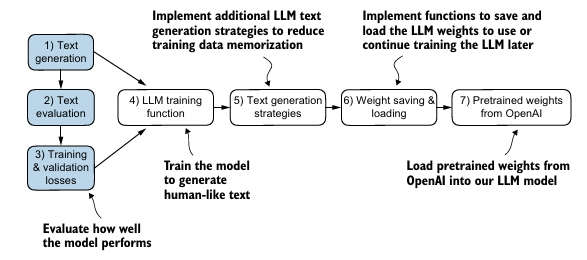

In [2]:
import tiktoken
import torch
import torch.nn as nn
import pandas as pd
from importlib.metadata import version

In [3]:
MODEL_CONFIG_124M = {
    "vocab_size": 50257,     
    "context_length": 1024,  
    "emb_dim": 768,          
    "n_heads": 12,           
    "n_layers": 12,          
    "drop_rate": 0.1,        
    "qkv_bias": False   
}

In [4]:
from components import *

In [5]:
torch.manual_seed(123)
model = GPTModel(MODEL_CONFIG_124M)


In [6]:
def text_to_token_ids(raw_text, tokenizer):
    encoded = tokenizer.encode(raw_text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)   
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)               
    return tokenizer.decode(flat.tolist())

## Calculating the text generation loss

In [7]:
tokenizer = tiktoken.get_encoding("gpt2")

In [8]:
inputs = torch.tensor(
    [
        [16833, 3626, 6100], # every effort moves
        [40, 1107, 588] # I really like
    ]
)

targets = torch.tensor(
    [
        [3626, 6100, 345], # effort moves you
        [1107, 588, 11311] # really like chocolate
    ]
)

In [9]:
with torch.no_grad():
    logits = model(inputs)

In [10]:
logits.shape

torch.Size([2, 3, 50257])

In [11]:
probas = torch.softmax(logits, dim=-1)
probas

tensor([[[1.9448e-05, 1.9032e-05, 2.8767e-05,  ..., 2.8202e-05,
          2.9893e-05, 1.1381e-05],
         [2.7345e-05, 6.6980e-06, 7.4837e-06,  ..., 1.0048e-05,
          1.4296e-05, 1.6058e-05],
         [3.7955e-05, 1.5079e-05, 1.7347e-05,  ..., 1.7443e-05,
          8.2702e-06, 2.6997e-05]],

        [[3.1914e-05, 1.6643e-05, 2.9416e-05,  ..., 8.7600e-06,
          2.3444e-05, 5.9002e-06],
         [2.3228e-05, 1.5799e-05, 2.0094e-05,  ..., 8.2202e-06,
          2.7843e-05, 1.5896e-05],
         [2.9573e-05, 1.8170e-05, 2.0259e-05,  ..., 1.3170e-05,
          1.2685e-05, 1.9956e-05]]])

In [12]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
token_ids

tensor([[[23799],
         [ 2662],
         [12752]],

        [[20522],
         [49289],
         [17284]]])

In [13]:
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Model Output batch 1: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

Targets batch 1:  effort moves you
Model Output batch 1:  TBOMousing


In [14]:
target_1_probas = probas[0, [0, 1, 2], targets[0]]
print("Prob of target -> (effort moves you):\n", target_1_probas)

Prob of target -> (effort moves you):
 tensor([2.5231e-05, 2.7292e-05, 1.4786e-05])


In [15]:
target_2_probas = probas[1, [0, 1, 2], targets[1]]
print("Prob of target -> (really like chocolate):\n", target_1_probas)

Prob of target -> (really like chocolate):
 tensor([2.5231e-05, 2.7292e-05, 1.4786e-05])


In [16]:
log_probas = torch.log(torch.cat((target_1_probas, target_2_probas)))
print(log_probas)

tensor([-10.5874, -10.5089, -11.1218, -10.3691, -11.4307, -11.9483])


In [17]:
avg_log_prob = torch.mean(log_probas)
avg_log_prob

tensor(-10.9944)

In [18]:
neg_avg_log_probas = -1 * avg_log_prob
neg_avg_log_probas # so called (cross-entropy loss). Our goal is to get this value very close to zero

tensor(10.9944)

## Pytorch cross entropy

In [19]:
loss = torch.nn.functional.cross_entropy(
    logits.flatten(0,1),
    targets.flatten())
loss

tensor(10.9944)

## Perplexity

In [20]:
perplexity = torch.exp(loss)
perplexity 

tensor(59538.6484)

## Calculating the training and validation set losses

In [25]:
from itertools import chain

file_path = "../data/sample.parquet"

df = pd.read_parquet(file_path, engine="fastparquet")
df["token_ids"] = df["token_ids"].apply(
    lambda list: [int(token_id) for token_id in list])

token_ids = list(chain.from_iterable(df["token_ids"]))
print(len(token_ids))

28672


In [26]:
train_ratio = 0.80
split_idx = int(train_ratio * len(token_ids))
train_data = token_ids[:split_idx]
val_data = token_ids[split_idx:]

In [27]:
train_loader = dataloader(
    train_data,
    batch_size=8,
    max_length=MODEL_CONFIG_124M["context_length"],
    stride=MODEL_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)
val_loader = dataloader(
    val_data,
    batch_size=8,
    max_length=MODEL_CONFIG_124M["context_length"],
    stride=MODEL_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [29]:
import torch, platform
print("Torch:", torch.__version__)
print("CUDA available?", torch.cuda.is_available())
print("Build CUDA:", torch.version.cuda)
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "—")
print("Python:", platform.python_version())


Torch: 2.2.0+cu118
CUDA available? True
Build CUDA: 11.8
Device: NVIDIA GeForce GTX 960M
Python: 3.10.19


In [30]:
def calc_batch_loss(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)        
    target_batch = target_batch.to(device)      
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)    
    else:
        num_batches = min(num_batches, len(data_loader))  
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_batch_loss(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item()   
        else:
            break
    return total_loss / num_batches

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)  
with torch.no_grad():                                       
    train_loss = calc_loss_loader(train_loader, model, device)   
    val_loss = calc_loss_loader(val_loader, model, device)
print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Training loss: 10.96968936920166
Validation loss: 10.967097282409668
